# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [40]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from optical_functions import LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric

import matplotlib.pyplot as plt 

from diffractsim import cm, mm, um 
import os

# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, ax=ax[0])
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase, ax=ax[1])
    plt.show()


# Create field & modes of interest following yaml configuration

In [63]:
stream = open(f"configs/ga1.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
num_of_output_chans = 4
output_chan_width = cnfg['output_chan_width'] * mm # in mm 
num_of_phase_maps = cnfg['num_maps']

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']

# Define the coordinate space 

la = 0.5*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
maxx = 1.5 * mm # Full length of the numerical window (m)
N=128 # [Number of points per dimension]

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)
h = dx

X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)


''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []
output_chans,_,_ = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans)

if(isKnot):
    for ii in range(len(knotType)):
        list_of_OAMs.append(oamModes(setKnotType(r, phi, w0, knotType[ii], shapeParams[ii]), output_chans[ii]))
        
else:
    for ii in range(len(LG_modes)):
        list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))


Plot output channels

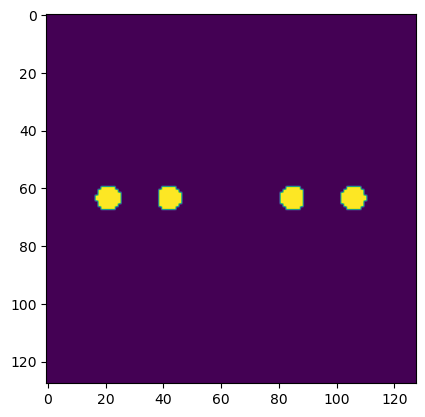

In [66]:
plt.imshow(np.abs(output_chans[0] + output_chans[1] + output_chans[2] + output_chans[3]))


Load genetic Instance

In [48]:
import pickle

instance_name = 'oam_sameShape_March7_twoMap'

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)

Compute phase screens and plot them 

[[-0.33151531 -0.75825867  0.78310962 ...  0.82919302 -0.30545949
   0.10230293]
 [ 0.77010155  0.71793843 -0.6632486  ... -0.9973709  -0.99834634
  -0.28929867]
 [ 0.99945698  0.8540015  -0.20458535 ... -0.399093   -0.98038699
  -0.75964841]
 ...
 [-0.8324532   0.37501343  0.78756569 ...  0.97595485  0.25277115
   0.95571062]
 [-0.26506073 -0.94633918  0.9567772  ... -0.76452386  0.30332986
  -0.81829299]
 [-0.98470207  0.66420643  0.54134428 ... -0.90052856  0.01680077
   0.61491579]]


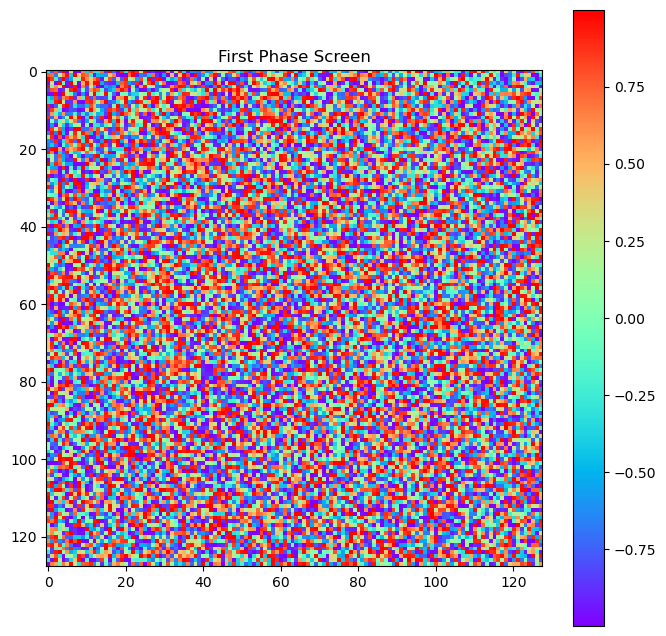

In [49]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=complex)

# Compute phase screens and plot them 
for ii in range(num_of_phase_maps):
    phase_maps[ii]= np.exp(1j*phase_out[ii,:,:])

#phaseScreenDos = np.exp(1j*phase_out[1,:,:])

fig, ax = plt.subplots(1,1, figsize=(8,8))

first = ax.imshow(np.angle(phase_maps[0]), cmap='rainbow')
ax.set_title("First Phase Screen")
c1 = fig.colorbar(first, ax=ax)

'''
second = ax[1].imshow(np.angle(phase_maps[1]), cmap='hsv')
ax[1].set_title("Second Phase Screen")
c2 = fig.colorbar(second, ax=ax[1])
'''

print(phase_out[0])
plt.show()

Let's also consider an actual hologram here

In [50]:
# This function generates phase gratings in reminisce of OAM gratings 

def OAMWithGratings(l,rows,cols,xoffset,yoffset,a):
    
    crow, ccol = int(rows / 2)+xoffset, int(cols / 2)+yoffset
    mask = np.zeros((rows,cols)) +0j
    fx = 10.0
    fy = 0.0
    phi = np.zeros((rows,cols))+0j

    for i in range (rows):
        for j in range (cols):
            
            x = i - crow
            y = j - ccol
            alpha = l*np.arctan2(x,y) + 2*np.pi*10*y/128
            g = a[0] + a[1]*np.cos(2*alpha)  + a[2]*np.cos(3*alpha) + a[3]*np.cos(4*alpha)
                  #g = 1/4*(1 + np.cos(alpha) + np.cos(2*alpha) +  np.cos(3*alpha)+np.cos(4*alpha))
                  #g = np.mod(alpha,2*np.pi)
            mask[i,j] = g
        
    return(mask)

test_mask = OAMWithGratings(1,N,N,0,0,[1,1,1,1])

Compute the propagation for each mode

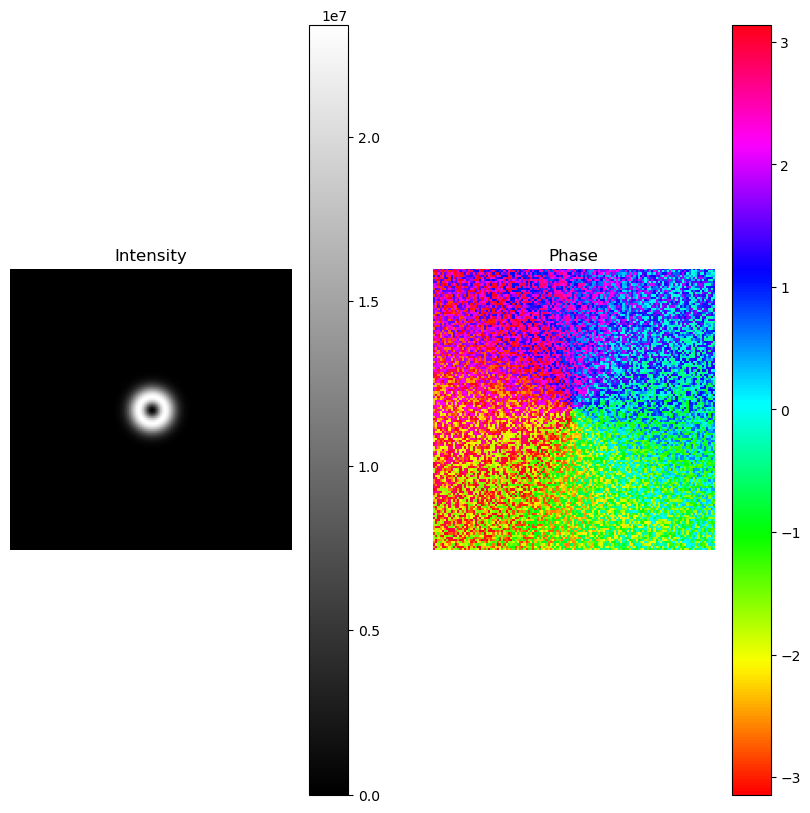

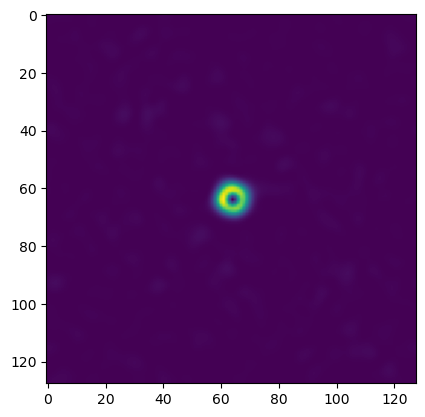

In [51]:
# Let's pick an LG beam to analyze

field = list_of_OAMs[-1].oamBeam 


# modulate the field by the first phase map 

field_mod_1 = field *np.exp(1j*phase_out[0])

TotInt(field_mod_1)

# let's simulate the propagation of the lens

field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)

# compute the field intensity 

final_field_int = np.abs(field_lens)**2
plt.imshow(final_field_int)

Simulating the second phase map

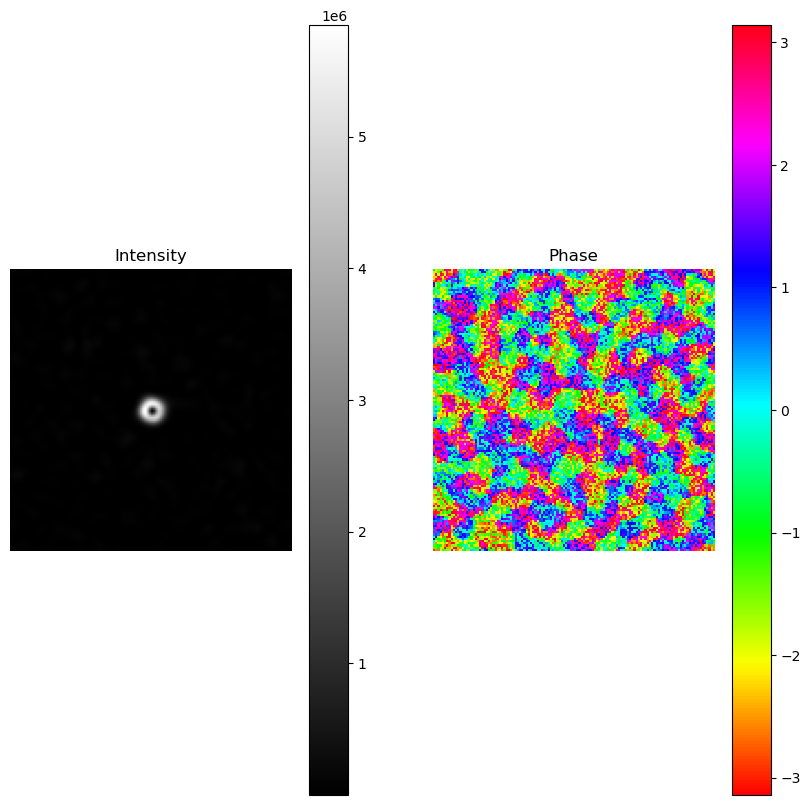

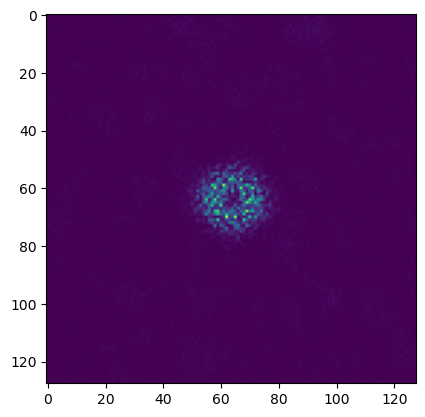

In [53]:
# modulate the field by the second phase map 

field_mod_2 = field_lens*np.exp(1j*phase_out[1])

TotInt(field_mod_2)

# simulate the lens field again. This is the final field. 

field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)


plt.imshow(abs(field_lens_2)**2)